# Convolutional Neural Networks.


- Extended version of ANN Designed specifically for Image based data.


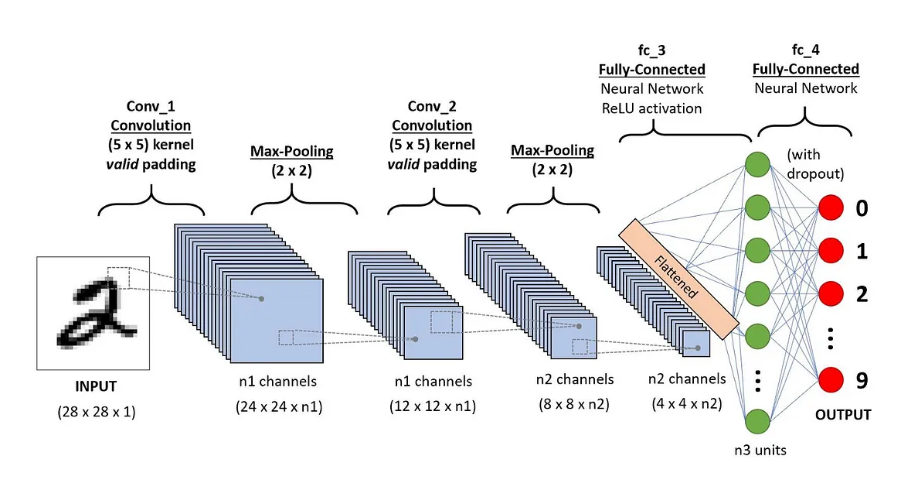

In [76]:
import os, warnings
import pandas as pd, numpy as np
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
import torchvision
import seaborn as sns
import matplotlib.pyplot as plt 
from tqdm import tqdm

Constants:

In [77]:
LEARNING_RATE = 0.001
EPOCHS = 2
BATCH_SIZE = 64

In [78]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5,), (0.5,))
    ]
)

In [86]:
train_dataset = MNIST(root='./dataset/mnist', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./dataset/mnist', train=False, download=True, transform=transform)

In [87]:
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=10)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=10)

In [88]:
# Device Selection:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

---

Building a CNN using PyTorch:

In [ ]:
class CNN(nn.Module):
    
    def __init__(self):
        super(CNN, self).__init__()

        self.cnn_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
        
    def forward(self, x):
        x = self.cnn_layers(x)
        # print(x.shape)
        x = self.fc_layer(x)
        return x

In [90]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

---
### Training the model:

In [91]:
for epoch in range(EPOCHS):
    
    model.train()
    running_loss = 0.0
    pbar = tqdm(total=len(trainloader))
    for inputs, target in trainloader:
        inputs = inputs.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
            outputs = model(inputs)
            # loss = sum(criterion(out, target) for out in outputs) / len(outputs)
            loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.update(1)
    
    pbar.close()
        
    print(f"Epoch [{epoch}/{EPOCHS}] loss: {running_loss/len(trainloader):.4f}")    
        
        

100%|██████████| 938/938 [02:05<00:00,  7.45it/s]


Epoch [0/2] loss: 0.1536


100%|██████████| 938/938 [01:56<00:00,  8.03it/s]

Epoch [1/2] loss: 0.0470


---
### Validate the model:

In [92]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    pbar = tqdm(total=len(testloader))
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs) 
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        pbar.update(1)
    pbar.close()
print(f"Test Accuracy: {100 * correct / total:.2f}%")

100%|██████████| 10/10 [00:10<00:00,  1.06s/it]

Test Accuracy: 98.87%


---


In [93]:
from PIL import Image

In [94]:
transform_ = torchvision.transforms.Compose([
    torchvision.transforms.Grayscale(),
    torchvision.transforms.Resize((28,28)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

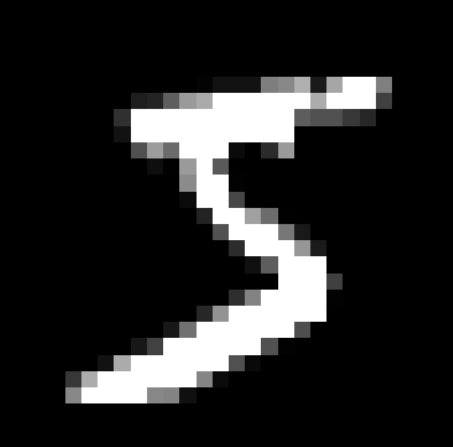

In [96]:
test_img_path = './dataset/mnist/sample_pred_data/five.png'
image = Image.open(test_img_path)
image

In [97]:
input_tensor = transform_(image).unsqueeze(0)
input_tensor = input_tensor.to(device)


model.eval()
with torch.no_grad():
    output = model(input_tensor)
    predicted = torch.argmax(output, dim=1)

print(f"Predicted Digit: {predicted.item()}")

Predicted Digit: 5


---
By Kirtan Ghelani $@SculptSoft$